TAHMİNLER TUTARLI MI?

1. Veriler yükleniyor...
   -> 2026 Tahmin Dosyası Okundu. (9 sektör)
   -> Klasörde 9 adet sektör dosyası bulundu.
2. Analiz yapılıyor...


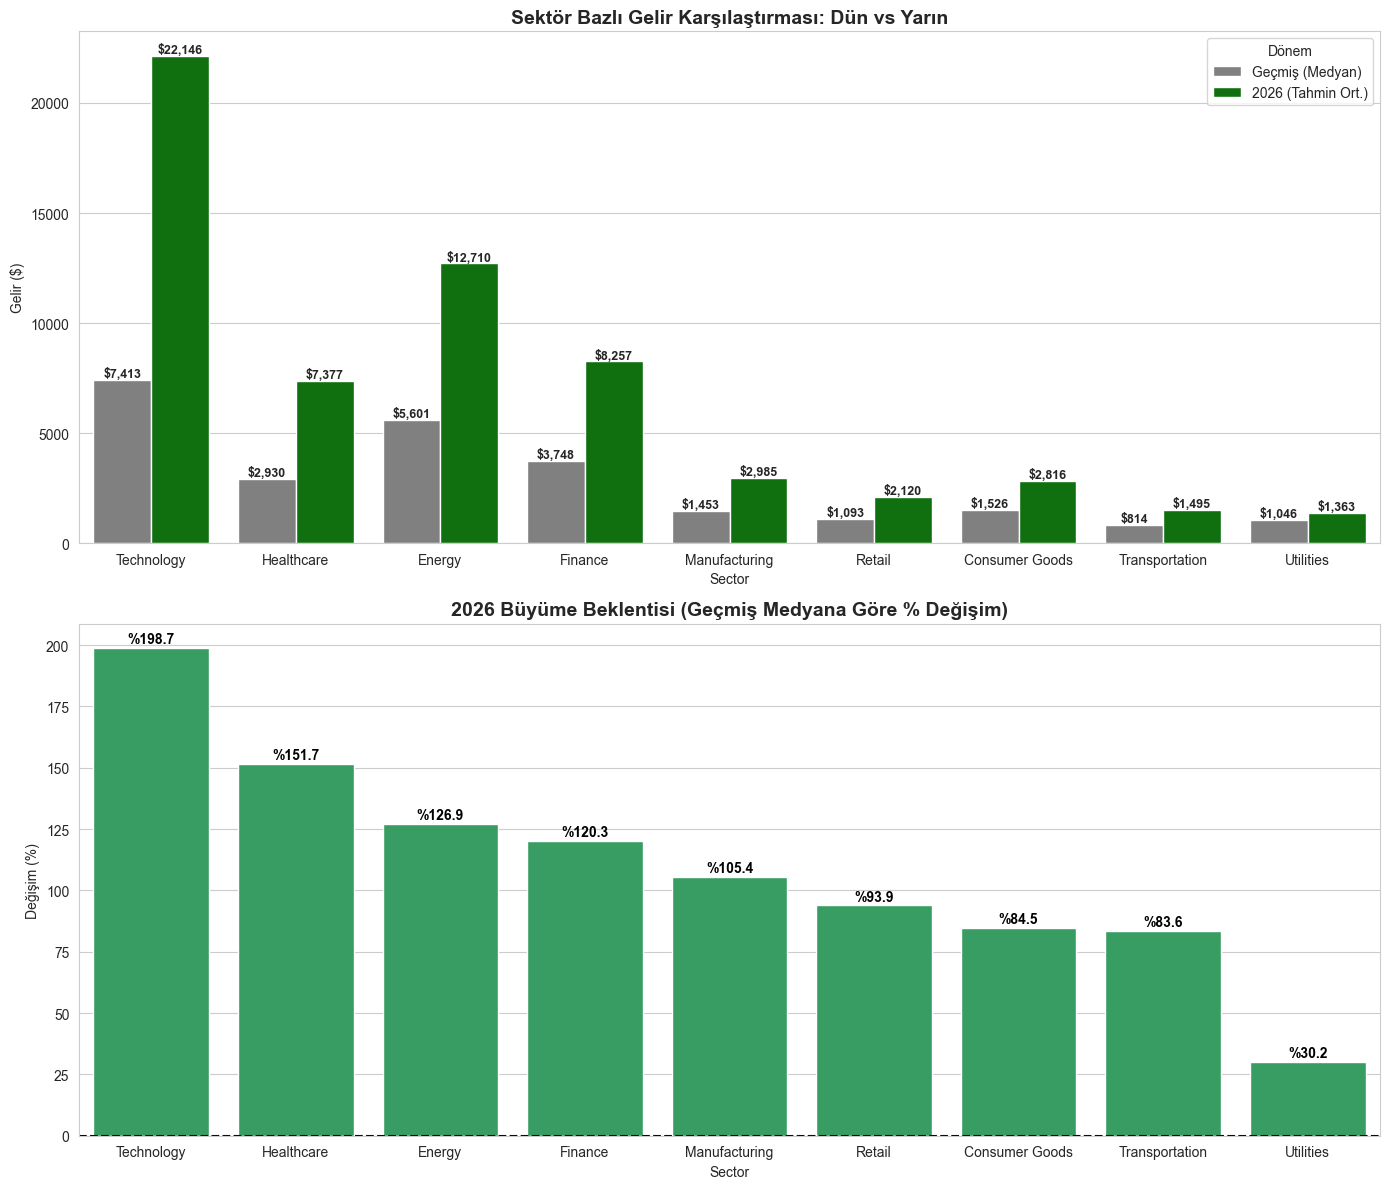


📊 SEKTÖREL PERFORMANS RAPORU (MEDYAN vs 2026 ORTALAMA)
Sektör               | Geçmiş Medyan   | 2026 Ort.       | Büyüme (%)
-------------------------------------------------------------------------------------
Technology           | $7,414          | $22,146         | %198.7    
Healthcare           | $2,931          | $7,377          | %151.7    
Energy               | $5,601          | $12,710         | %126.9    
Finance              | $3,748          | $8,257          | %120.3    
Manufacturing        | $1,453          | $2,985          | %105.4    
Retail               | $1,094          | $2,120          | %93.9     
Consumer Goods       | $1,526          | $2,816          | %84.5     
Transportation       | $814            | $1,495          | %83.6     
Utilities            | $1,047          | $1,363          | %30.2     
-------------------------------------------------------------------------------------
NOT: Bu analizde, şirketlerin geçmiş performansının 'orta noktası' (Medy

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------------------------------------------------------
# AYARLAR 
# ---------------------------------------------------------
# Ham veri setlerinin (Sector_*.csv) olduğu klasör:
DATASETS_FOLDER = r"../../../data/by_sector"

# Modelin ürettiği 2026 Sektör Tahmin dosyası (Kodun çalıştığı yerde olmalı):
PREDICTION_FILE = "../../../results/tables/2026_sector_averages_metrics.csv"

# ---------------------------------------------------------
# 1. VERİLERİN YÜKLENMESİ
# ---------------------------------------------------------
print("1. Veriler yükleniyor...")

# A) 2026 Tahminlerini Oku (Sektör Bazlı)
try:
    df_2026 = pd.read_csv(PREDICTION_FILE)
    # Sütun isimlerindeki boşlukları temizle (Garanti olsun)
    df_2026.columns = df_2026.columns.str.strip()
    print(f"   -> 2026 Tahmin Dosyası Okundu. ({len(df_2026)} sektör)")
except FileNotFoundError:
    print(f"HATA: '{PREDICTION_FILE}' bulunamadı. Lütfen dosya yolunu kontrol edin.")
    df_2026 = pd.DataFrame()

# B) Geçmiş Verileri Tara ve Medyan Hesapla
historical_data = []

if os.path.exists(DATASETS_FOLDER):
    # Klasördeki tüm dosyaları listele
    files = [f for f in os.listdir(DATASETS_FOLDER) if f.startswith("Sector_") and f.endswith(".csv")]
    
    print(f"   -> Klasörde {len(files)} adet sektör dosyası bulundu.")
    
    for filename in files:
        try:
            # Dosya isminden Sektör Adını çıkar (Sector_Consumer_Goods.csv -> Consumer Goods)
            sector_name = filename.replace("Sector_", "").replace(".csv", "").replace("_", " ")
            
            # CSV'yi oku
            file_path = os.path.join(DATASETS_FOLDER, filename)
            df_temp = pd.read_csv(file_path)
            
            # Sütun isimlerini temizle (Örn: " Revenue " -> "Revenue")
            df_temp.columns = df_temp.columns.str.strip()
            
            if 'Revenue' in df_temp.columns:
                # Geçmiş yılların medyanını al
                median_revenue = df_temp['Revenue'].median()
                historical_data.append({'Sector': sector_name, 'Historical_Median': median_revenue})
            else:
                print(f"UYARI: {filename} içinde 'Revenue' sütunu yok.")
                
        except Exception as e:
            print(f"HATA: {filename} okunurken sorun çıktı -> {e}")
else:
    print(f"HATA: Klasör yolu bulunamadı: {DATASETS_FOLDER}")

# Listeyi DataFrame'e çevir
df_hist = pd.DataFrame(historical_data)

# ---------------------------------------------------------
# 2. VERİ BİRLEŞTİRME VE ANALİZ
# ---------------------------------------------------------
print("2. Analiz yapılıyor...")

if not df_hist.empty and not df_2026.empty:
    # İki tabloyu 'Sector' sütunu üzerinden birleştir
    merged = pd.merge(df_2026, df_hist, on='Sector', how='inner')
    
    # Fark Hesapla
    # 2026 Tahmini (Ortalama) vs Geçmiş (Medyan)
    merged['Diff'] = merged['2026_Avg_Revenue'] - merged['Historical_Median']
    merged['Growth_%'] = (merged['Diff'] / merged['Historical_Median']) * 100
    
    # Sıralama (En çok büyüyecek olandan en aza)
    merged = merged.sort_values('Growth_%', ascending=False)
    
    # ---------------------------------------------------------
    # 3. GÖRSELLEŞTİRME
    # ---------------------------------------------------------
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(2, 1, figsize=(14, 12))
    
    # GRAFİK 1: Karşılaştırmalı Bar Grafiği
    # Veriyi görselleştirmek için format değiştir (Melt)
    df_plot = merged.melt(id_vars='Sector', 
                          value_vars=['Historical_Median', '2026_Avg_Revenue'], 
                          var_name='Type', value_name='Revenue')
    
    df_plot['Type'] = df_plot['Type'].replace({
        'Historical_Median': 'Geçmiş (Medyan)',
        '2026_Avg_Revenue': '2026 (Tahmin Ort.)'
    })
    
    sns.barplot(data=df_plot, x='Sector', y='Revenue', hue='Type', palette=['gray', 'green'], ax=ax[0])
    
    # Barların üzerine değer yazma
    for p in ax[0].patches:
        if p.get_height() > 0:
            ax[0].annotate(f"${int(p.get_height()):,}", 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='bottom', fontsize=9, fontweight='bold')
            
    ax[0].set_title("Sektör Bazlı Gelir Karşılaştırması: Dün vs Yarın", fontsize=14, fontweight='bold')
    ax[0].set_ylabel("Gelir ($)")
    ax[0].legend(title="Dönem")
    
    # GRAFİK 2: Büyüme Farkı (%)
    # Renkler: Pozitif yeşil, negatif kırmızı
    colors = ['#27ae60' if x > 0 else '#c0392b' for x in merged['Growth_%']]
    sns.barplot(data=merged, x='Sector', y='Growth_%', palette=colors, ax=ax[1])
    
    ax[1].axhline(0, color='black', linestyle='--')
    ax[1].set_title("2026 Büyüme Beklentisi (Geçmiş Medyana Göre % Değişim)", fontsize=14, fontweight='bold')
    ax[1].set_ylabel("Değişim (%)")
    
    # Yüzdeleri yazma
    for i, v in enumerate(merged['Growth_%']):
        ax[1].text(i, v + (2 if v > 0 else -5), f"%{v:.1f}", ha='center', fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()
    
    # ---------------------------------------------------------
    # 4. TABLO ÇIKTISI
    # ---------------------------------------------------------
    print("\n" + "="*85)
    print("📊 SEKTÖREL PERFORMANS RAPORU (MEDYAN vs 2026 ORTALAMA)")
    print("="*85)
    print(f"{'Sektör':<20} | {'Geçmiş Medyan':<15} | {'2026 Ort.':<15} | {'Büyüme (%)':<10}")
    print("-" * 85)
    
    for i, row in merged.iterrows():
        print(f"{row['Sector']:<20} | ${row['Historical_Median']:<14,.0f} | ${row['2026_Avg_Revenue']:<14,.0f} | %{row['Growth_%']:<9.1f}")
    
    print("-" * 85)
    print("NOT: Bu analizde, şirketlerin geçmiş performansının 'orta noktası' (Medyan) ile")
    print("modelin 2026 için tahmin ettiği genel 'ortalama' (Average) kıyaslanmıştır.")

else:
    print("\nKRİTİK HATA: Veriler birleştirilemedi.")
    print("Lütfen dosya isimlerinin (Sector_X.csv) ve tahmin dosyasındaki sektör isimlerinin (X) aynı olduğundan emin olun.")

MODELİN ANALİZİ


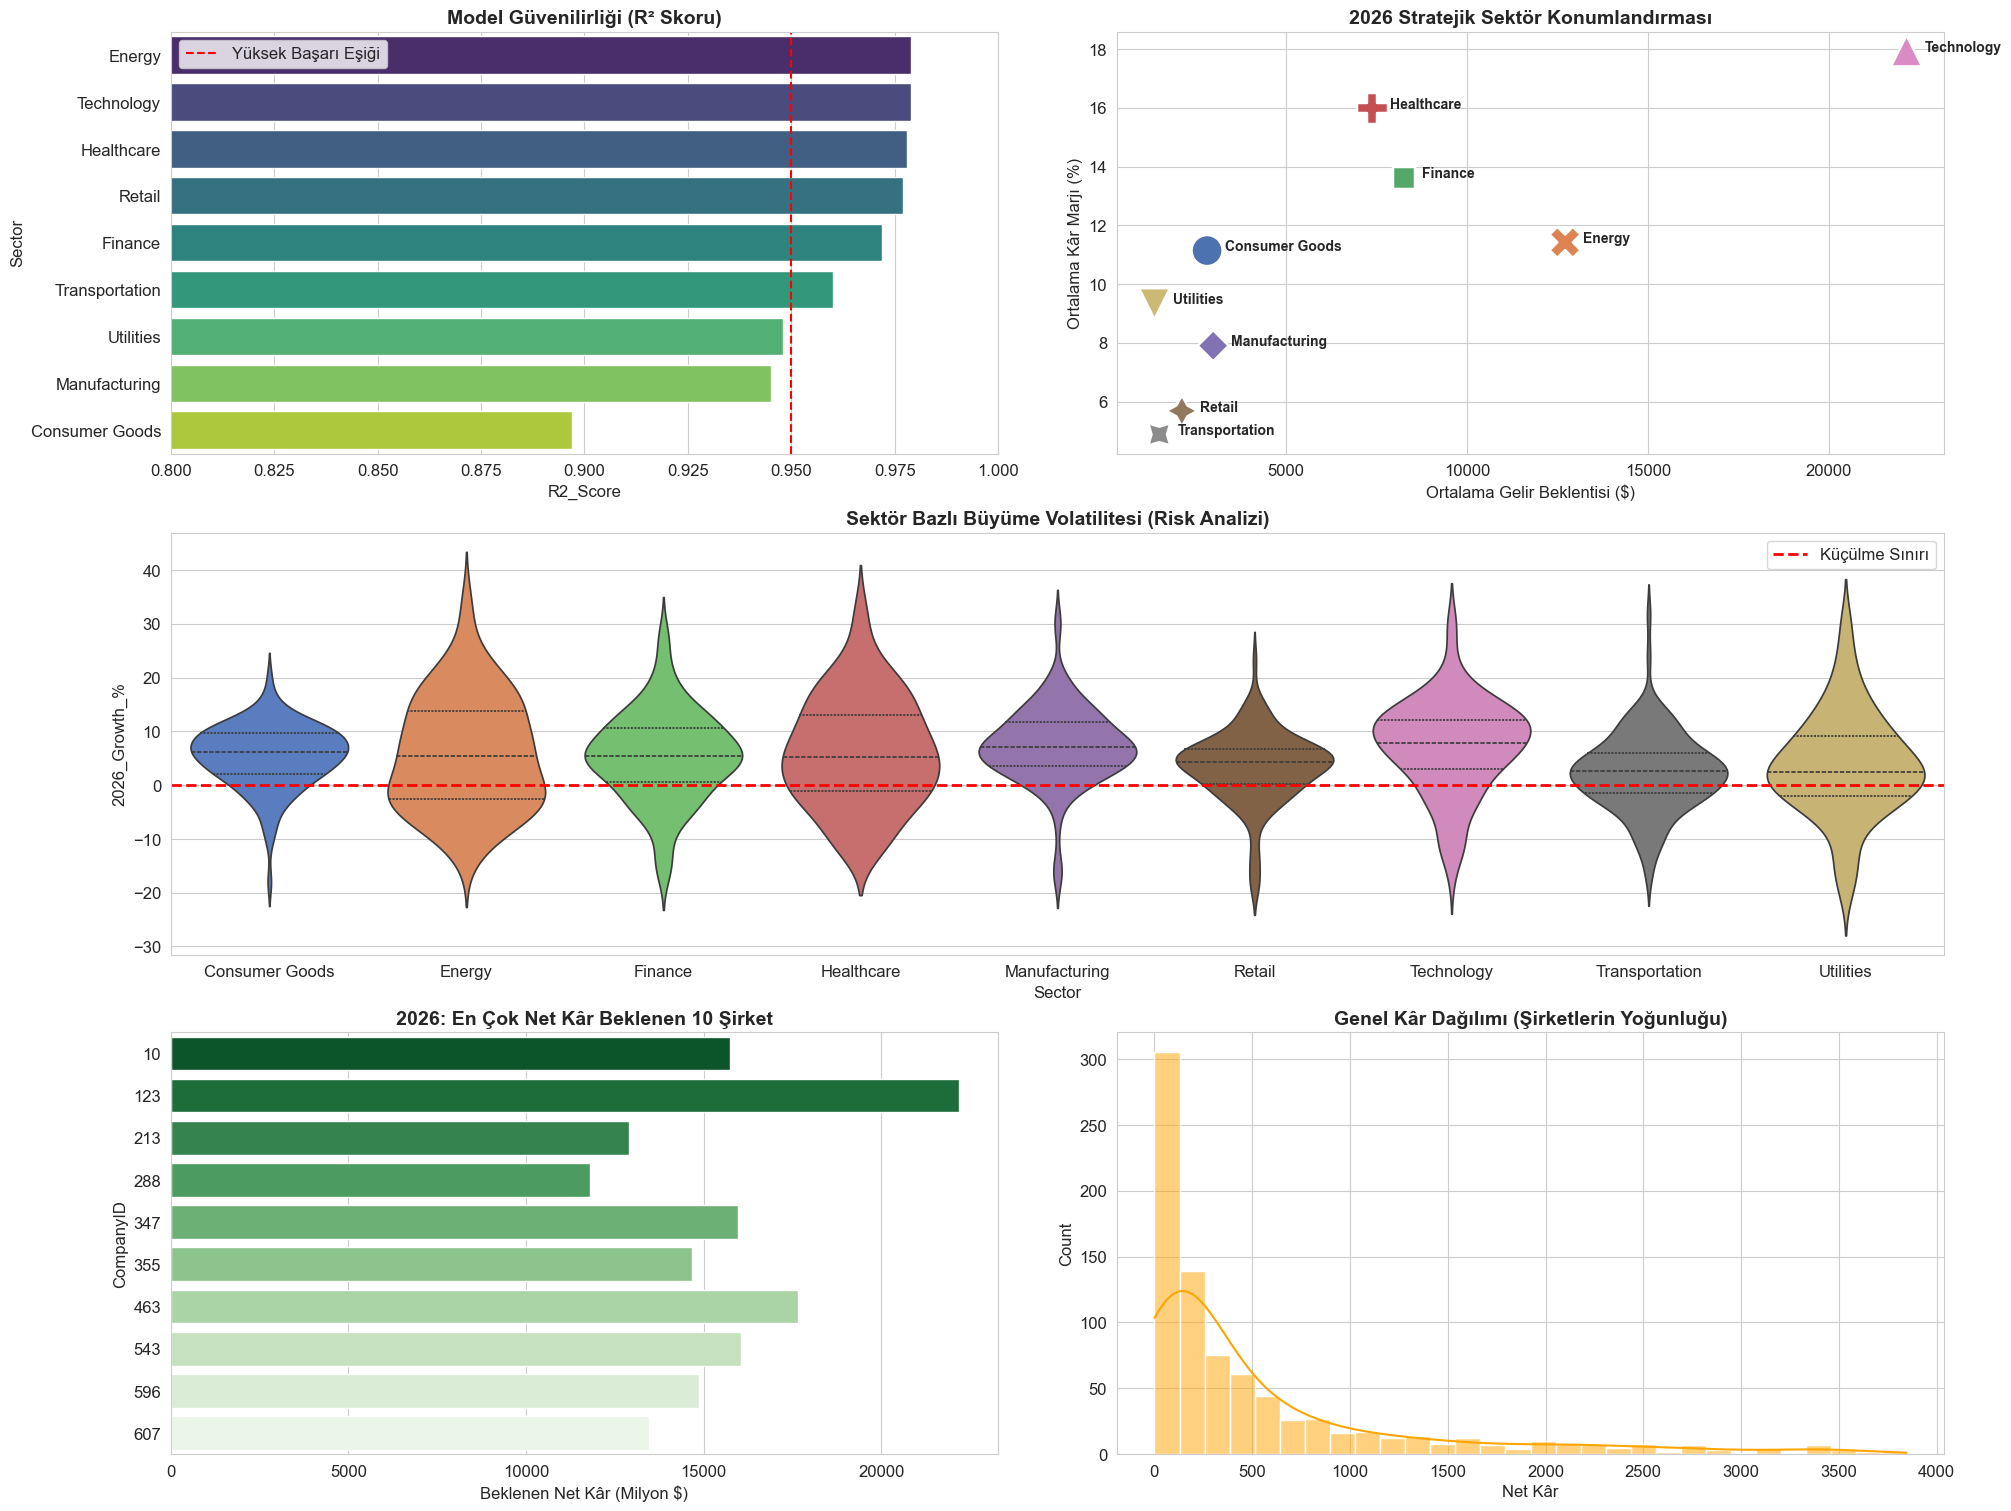


🏆 SEKTÖR LİDERLERİ (EN YÜKSEK ORTALAMA KÂR)
           Sector  2026_Avg_Margin  2026_Avg_Revenue
6      Technology            17.94           22146.0
3      Healthcare            15.99            7377.0
2         Finance            13.62            8257.0
1          Energy            11.42           12710.0
0  Consumer Goods            11.14            2816.0
8       Utilities             9.33            1363.0
4   Manufacturing             7.90            2985.0
5          Retail             5.68            2120.0
7  Transportation             4.88            1495.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# 1. VERİ YÜKLEME VE HAZIRLIK
# ---------------------------------------------------------
# Dosyaları yükle
df_perf = pd.read_csv("../../../results/tables/sector_performance_summary_metrics.csv")
df_avg = pd.read_csv("../../../results/tables/2026_sector_averages_metrics.csv")
df_comp = pd.read_csv("../../../results/tables/2026_all_companies_predictions_metrics.csv")

# Net Kâr Hesabı (Gelir * Marj / 100)
df_comp['Expected_Profit_2026'] = df_comp['2026_Predicted_Revenue'] * (df_comp['2026_Predicted_ProfitMargin_%'] / 100)

# Görsel ayarları
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 15)
plt.rcParams['font.size'] = 12

# Ana figür oluştur (3 Satır, 2 Sütunluk bir düzen)
fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(3, 2)

# ---------------------------------------------------------
# GRAFİK 1: MODEL GÜVENİLİRLİĞİ (R2 SKORU)
# ---------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(data=df_perf.sort_values("R2_Score", ascending=False), 
            x="R2_Score", y="Sector", palette="viridis", ax=ax1)
ax1.set_title("Model Güvenilirliği (R² Skoru)", fontsize=14, fontweight='bold')
ax1.set_xlim(0.8, 1.0) 
ax1.axvline(0.95, color='red', linestyle='--', label='Yüksek Başarı Eşiği')
ax1.legend()

# ---------------------------------------------------------
# GRAFİK 2: SEKTÖR MATRİSİ (GELİR vs KÂRLILIK)
# ---------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
sns.scatterplot(data=df_avg, x="2026_Avg_Revenue", y="2026_Avg_Margin", 
                hue="Sector", s=500, style="Sector", palette="deep", ax=ax2, legend=False)

# Etiketler
for i in range(df_avg.shape[0]):
    ax2.text(df_avg['2026_Avg_Revenue'][i]+500, df_avg['2026_Avg_Margin'][i], 
             df_avg['Sector'][i], fontsize=10, weight='bold')

ax2.set_title("2026 Stratejik Sektör Konumlandırması", fontsize=14, fontweight='bold')
ax2.set_xlabel("Ortalama Gelir Beklentisi ($)")
ax2.set_ylabel("Ortalama Kâr Marjı (%)")

# ---------------------------------------------------------
# GRAFİK 3: RİSK ANALİZİ (BÜYÜME DAĞILIMI - VIOLIN PLOT)
# ---------------------------------------------------------
ax3 = fig.add_subplot(gs[1, :]) # Tüm satırı kaplasın
# Aykırı değerleri temizle (Görsel netliği için %1 ve %99 dilimlerini al)
q_low = df_comp['2026_Growth_%'].quantile(0.01)
q_high = df_comp['2026_Growth_%'].quantile(0.99)
df_growth_filtered = df_comp[(df_comp['2026_Growth_%'] > q_low) & (df_comp['2026_Growth_%'] < q_high)]

sns.violinplot(data=df_growth_filtered, x="Sector", y="2026_Growth_%", palette="muted", inner="quartile", ax=ax3)
ax3.axhline(0, color='red', linestyle='--', linewidth=2, label="Küçülme Sınırı")
ax3.set_title("Sektör Bazlı Büyüme Volatilitesi (Risk Analizi)", fontsize=14, fontweight='bold')
ax3.legend()

# ---------------------------------------------------------
# GRAFİK 4: EN YÜKSEK KÂR EDECEK TOP 10 ŞİRKET
# ---------------------------------------------------------
ax4 = fig.add_subplot(gs[2, 0])
top_10_profit = df_comp.sort_values("Expected_Profit_2026", ascending=False).head(10)
sns.barplot(data=top_10_profit, x="Expected_Profit_2026", y="CompanyID", 
            palette="Greens_r", orient='h', ax=ax4)
ax4.set_title("2026: En Çok Net Kâr Beklenen 10 Şirket", fontsize=14, fontweight='bold')
ax4.set_xlabel("Beklenen Net Kâr (Milyon $)")

# ---------------------------------------------------------
# GRAFİK 5: KÂR DAĞILIMI (HISTOGRAM)
# ---------------------------------------------------------
ax5 = fig.add_subplot(gs[2, 1])
# Görsel netliği için filtreli veri
profit_filtered = df_comp[(df_comp['Expected_Profit_2026'] > 0) & 
                          (df_comp['Expected_Profit_2026'] < df_comp['Expected_Profit_2026'].quantile(0.95))]

sns.histplot(data=profit_filtered, x="Expected_Profit_2026", kde=True, bins=30, color="orange", ax=ax5)
ax5.set_title("Genel Kâr Dağılımı (Şirketlerin Yoğunluğu)", fontsize=14, fontweight='bold')
ax5.set_xlabel("Net Kâr")

plt.show()

# ---------------------------------------------------------
# ÖZET TABLO YAZDIRMA
# ---------------------------------------------------------
print("\n" + "="*50)
print("🏆 SEKTÖR LİDERLERİ (EN YÜKSEK ORTALAMA KÂR)")
print("="*50)
print(df_avg.sort_values("2026_Avg_Margin", ascending=False)[['Sector', '2026_Avg_Margin', '2026_Avg_Revenue']])


TAHMİNLERİN GÖRSELLEŞTİRİLMESİ


Veriler yüklendi.
Toplam Şirket Tahmini: 1000
--------------------------------------------------


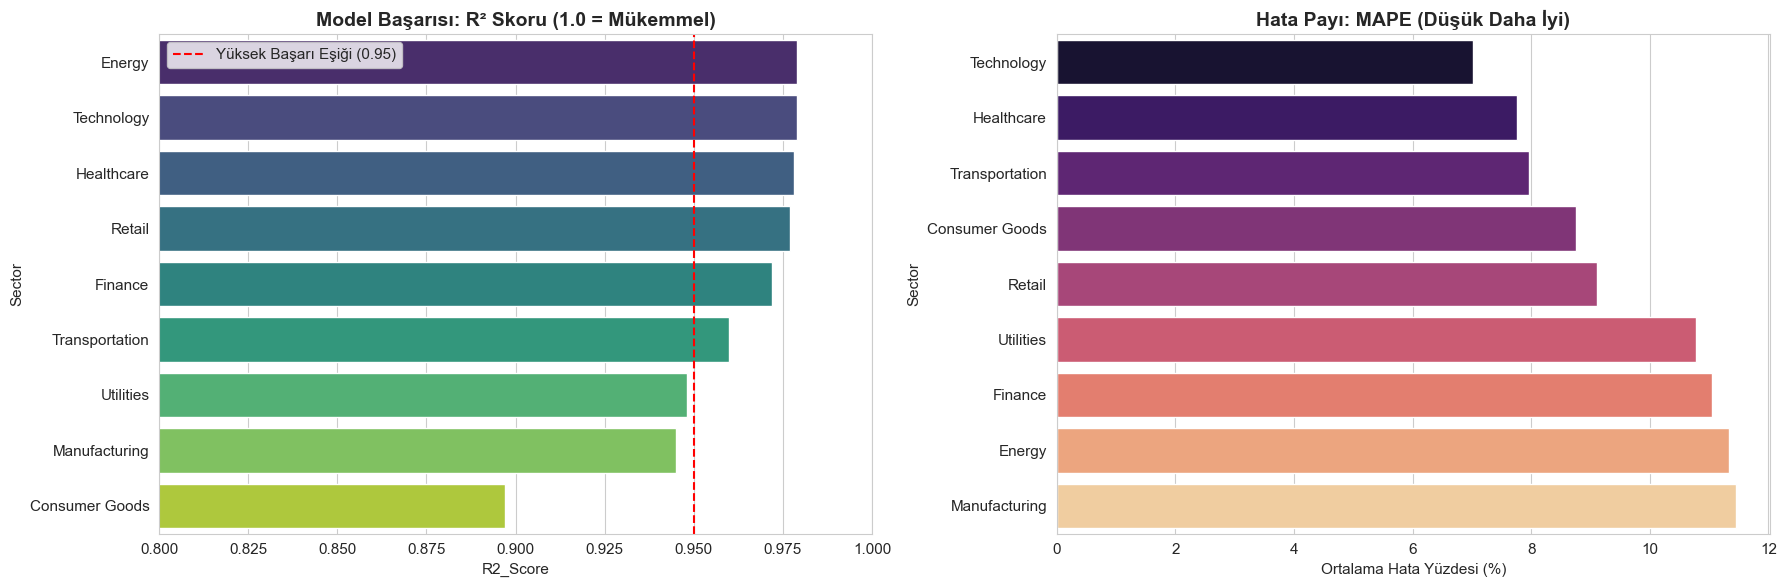

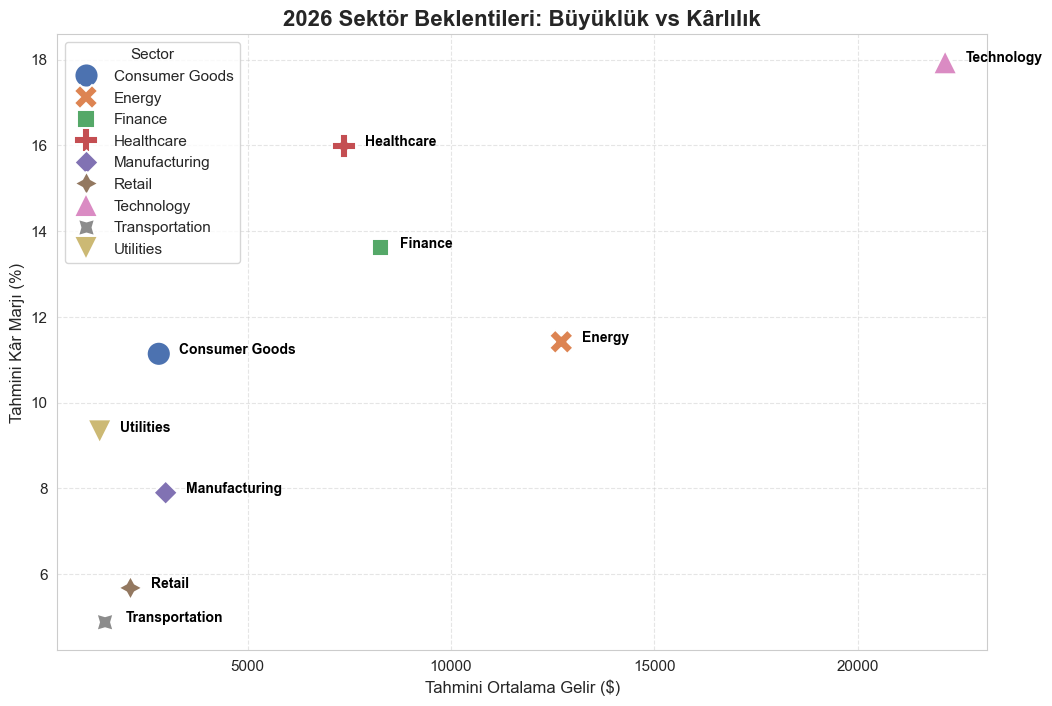

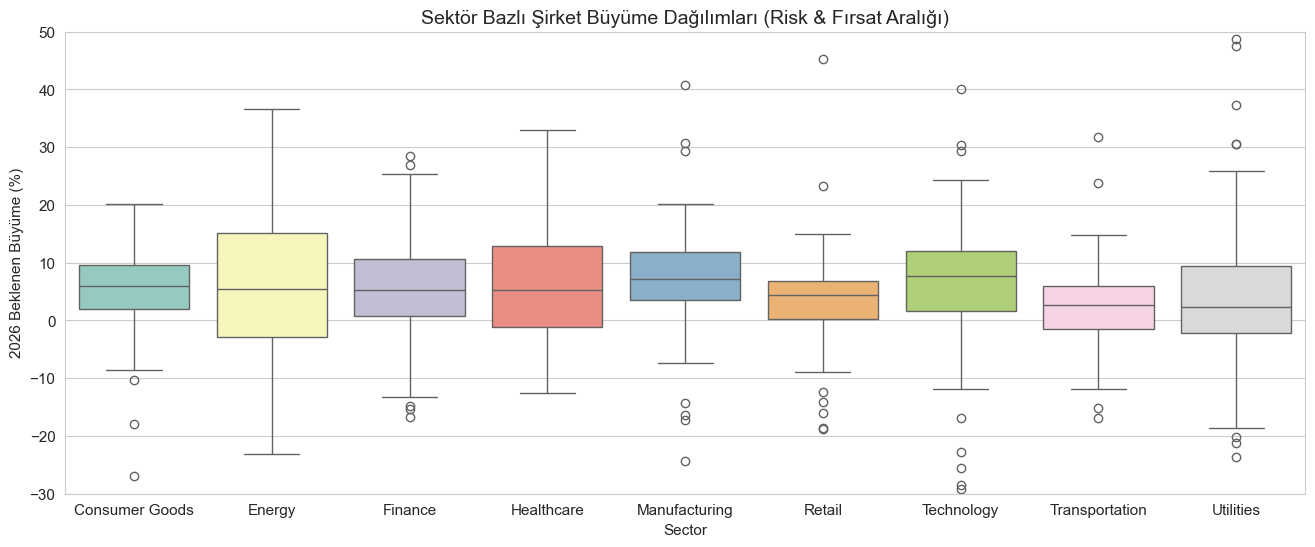


🏆 2026'NIN YILDIZ ADAYLARI (Yüksek Büyüme + Yüksek Marj)


,CompanyID,Sector,2026_Predicted_Revenue,2026_Growth_%,2026_Predicted_ProfitMargin_%
324,871,Finance,477.3,81.68,16.63
989,900,Utilities,848.4,47.58,22.21
724,432,Technology,954.4,40.14,26.44
196,653,Energy,49.1,36.68,31.11
384,411,Healthcare,14866.3,33.02,14.91
347,54,Healthcare,17686.2,32.82,22.74
861,714,Transportation,173.1,31.72,11.98
484,198,Manufacturing,483.9,30.77,14.55
949,516,Utilities,330.1,30.52,11.95
722,378,Technology,3331.3,30.42,33.31



⚠️ RİSKLİ / KÜÇÜLEN ŞİRKETLER (En Fazla Daralma)


,CompanyID,Sector,2026_Predicted_Revenue,2026_Growth_%,2026_Predicted_ProfitMargin_%
202,759,Energy,97343.1,-42.40,-6.98
684,19,Technology,128145.2,-29.13,0.50
729,463,Technology,103585.3,-28.47,17.04
112,988,Consumer Goods,12769.1,-27.00,3.32
703,213,Technology,42990.4,-25.56,30.01
561,891,Manufacturing,22783.3,-24.29,5.13
893,17,Utilities,3538.6,-23.58,16.60
193,646,Energy,103314.2,-23.05,10.04
696,123,Technology,106523.0,-22.74,20.82
914,214,Utilities,3675.2,-21.15,15.27


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Görsel ayarları
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# ---------------------------------------------------------
# 1. VERİLERİN YÜKLENMESİ
# ---------------------------------------------------------
# Dosya isimlerinin önceki adımla aynı olduğundan emin ol
df_perf = pd.read_csv("Sector_Performance_Summary_Metrics.csv")
df_avg = pd.read_csv("2026_Sector_Averages_Metrics.csv")
df_comp = pd.read_csv("2026_All_Companies_Predictions_Metrics.csv")

print(f"Veriler yüklendi.")
print(f"Toplam Şirket Tahmini: {len(df_comp)}")
print("-" * 50)

# ---------------------------------------------------------
# 2. MODEL PERFORMANS ANALİZİ (TEKNİK DEĞERLENDİRME)
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# A) R2 Skoru (Model Açıklayıcılığı)
sns.barplot(data=df_perf.sort_values("R2_Score", ascending=False), 
            x="R2_Score", y="Sector", palette="viridis", ax=ax[0])
ax[0].set_title("Model Başarısı: R² Skoru (1.0 = Mükemmel)", fontsize=14, fontweight='bold')
ax[0].set_xlim(0.8, 1.0) # Farkları görmek için zoom yapıyoruz
ax[0].axvline(0.95, color='red', linestyle='--', label='Yüksek Başarı Eşiği (0.95)')
ax[0].legend()

# B) MAPE (Hata Payı)
sns.barplot(data=df_perf.sort_values("MAPE_Revenue"), 
            x="MAPE_Revenue", y="Sector", palette="magma", ax=ax[1])
ax[1].set_title("Hata Payı: MAPE (Düşük Daha İyi)", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Ortalama Hata Yüzdesi (%)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. 2026 STRATEJİK SEKTÖR MATRİSİ
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))

# Scatter Plot: Gelir vs Marj
scatter = sns.scatterplot(data=df_avg, x="2026_Avg_Revenue", y="2026_Avg_Margin", 
                          hue="Sector", style="Sector", s=300, palette="deep")

plt.title("2026 Sektör Beklentileri: Büyüklük vs Kârlılık", fontsize=16, fontweight='bold')
plt.xlabel("Tahmini Ortalama Gelir ($)", fontsize=12)
plt.ylabel("Tahmini Kâr Marjı (%)", fontsize=12)

# Her noktanın üzerine sektör ismini yaz
for i in range(df_avg.shape[0]):
    plt.text(x=df_avg['2026_Avg_Revenue'][i] + 500, 
             y=df_avg['2026_Avg_Margin'][i], 
             s=df_avg['Sector'][i], 
             fontdict=dict(color='black', size=10, weight='bold'))

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# ---------------------------------------------------------
# 4. ŞİRKET BAZLI FIRSAT ANALİZİ
# ---------------------------------------------------------
# Sektörlere göre büyüme dağılımı (Risk analizi)
plt.figure(figsize=(16, 6))
sns.boxplot(data=df_comp, x="Sector", y="2026_Growth_%", palette="Set3")
plt.title("Sektör Bazlı Şirket Büyüme Dağılımları (Risk & Fırsat Aralığı)", fontsize=14)
plt.ylim(-30, 50) # Aşırı uç değerleri (varsa) grafiği bozmasın diye sınırladık
plt.ylabel("2026 Beklenen Büyüme (%)")
plt.show()

# ---------------------------------------------------------
# 5. "GİZLİ CEVHERLER" VE "ALARM VERENLER" TABLOSU
# ---------------------------------------------------------
# Filtre: Hem büyümesi pozitif hem kâr marjı %10 üzeri olan "Yıldız" şirketler
stars = df_comp[(df_comp['2026_Growth_%'] > 15) & (df_comp['2026_Predicted_ProfitMargin_%'] > 10)]
stars = stars.sort_values("2026_Growth_%", ascending=False).head(10)

# Filtre: Küçülmesi beklenen büyük şirketler
risky = df_comp[df_comp['2026_Growth_%'] < -10].sort_values("2026_Growth_%", ascending=True).head(10)

print("\n" + "="*60)
print("🏆 2026'NIN YILDIZ ADAYLARI (Yüksek Büyüme + Yüksek Marj)")
print("="*60)
display(stars[['CompanyID', 'Sector', '2026_Predicted_Revenue', '2026_Growth_%', '2026_Predicted_ProfitMargin_%']])

print("\n" + "="*60)
print("⚠️ RİSKLİ / KÜÇÜLEN ŞİRKETLER (En Fazla Daralma)")
print("="*60)
display(risky[['CompanyID', 'Sector', '2026_Predicted_Revenue', '2026_Growth_%', '2026_Predicted_ProfitMargin_%']])